# Baseline Catboost Model

In [2]:
%%capture
! pip install catboost

In [3]:
import pandas as pd, numpy as np, \
seaborn as sns, matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

merged = pd.read_csv('merged.csv', index_col = 0)
merged.head()

,player_id,name_x,position_x,team_x,season_x,conference,usage_passing_downs,usage_standard_downs,usage_third_down,usage_second_down,usage_first_down,usage_rush,usage_var_pass,usage_overall,avg_ppa_passing_downs,avg_ppa_standard_downs,avg_ppa_third_down,avg_ppa_second_down,avg_ppa_first_down,avg_ppa_rush,avg_ppa_var_pass,avg_ppa_all,total_ppa_passing_downs,total_ppa_standard_downs,total_ppa_third_down,total_ppa_second_down,total_ppa_first_down,total_ppa_rush,total_ppa_var_pass,total_ppa_all,fumbles_FUM,fumbles_LOST,fumbles_REC,passing_ATT,passing_COMPLETIONS,passing_INT,passing_PCT,passing_TD,passing_YDS,passing_YPA,receiving_LONG,receiving_REC,receiving_TD,receiving_YDS,receiving_YPR,rushing_ATT,rushing_LONG,rushing_TD,rushing_YDS,rushing_YPC,college_athlete_id,nfl_athlete_id,college_id,college_team,college_conference,nfl_team_id,nfl_team,position_y,name_y,year,round_x,pick_number,overall,height_in,weight_lbs,pre_draft_position_ranking,pre_draft_grade,pfr_player_id,cfb_player_id,season_y,round_y,pick,team_y,pfr_player_name,position,category,college,w_av,car_av,dr_av,ht,wt,forty,bench,vertical,broad_jump,cone,shuttle,pfr_id,birth_date,height,weight,rookie_season,last_season,birth_year,age
0,100009,Johnny Jackson,WR,Arizona,2015,PAC,0.104000,0.049000,0.094000,0.065000,0.055000,0.000000,0.133000,0.065000,0.953000,0.413000,1.314000,0.839000,0.415000,NaN,0.674,0.6740,28.600000,13.214000,22.345000,16.772000,9.542000,0.000000,41.813000,41.813000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.0,50.0,5.0,612.0,12.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,102597,Will Rogers,QB,Washington,2024,B1G,0.670000,0.458333,0.652167,0.532667,0.454333,0.060167,0.888000,0.520333,0.443833,0.188333,0.426833,0.438667,0.138167,-0.1675,0.313,0.2910,57.095833,43.996000,36.587833,45.864333,24.582667,-3.056667,104.148667,101.092333,4.5,2.166667,0.5,336.166667,226.333333,6.166667,0.666333,16.833333,2431.5,7.333333,NaN,NaN,NaN,NaN,NaN,34.000000,17.500000,0.333333,-71.333333,-1.916667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,107494,Trey Sanders,RB,TCU,2024,B12,0.043400,0.068400,0.047267,0.071533,0.058267,0.119733,0.008867,0.060600,0.646133,0.010467,0.280800,-0.090933,-0.006867,0.1442,NaN,0.1604,2.071933,2.040267,3.381200,-0.835133,-0.067467,3.438600,0.674133,4.112733,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.466667,15.333333,2.066667,128.733333,4.173333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,109907,Jon Lee,RB,Air Force,2014,MWC,0.035000,0.025000,0.015000,0.057000,0.015000,0.023000,0.052000,0.028000,0.630000,-0.128000,-0.363000,0.173000,0.222000,0.1790,0.015,0.1240,1.890000,-0.770000,-0.363000,1.040000,0.444000,1.076000,0.044000,1.120000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,2.0,0.0,12.0,6.0,6.000000,32.000000,0.000000,39.000000,6.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,136429,Cedric Patterson III,WR,Rice,2022,CUSA,0.077333,0.033667,0.116667,0.018000,0.045000,0.022667,0.086667,0.050667,0.224000,0.066333,0.166000,NaN,0.191333,0.1360,0.150,0.1760,6.349333,6.364667,3.909000,2.029667,6.775333,0.465333,12.248333,12.714000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.666667,15.333333,0.333333,16.000000,7.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
merged.columns

Index(['player_id', 'name_x', 'position_x', 'team_x', 'season_x', 'conference',
       'usage_passing_downs', 'usage_standard_downs', 'usage_third_down',
       'usage_second_down', 'usage_first_down', 'usage_rush', 'usage_var_pass',
       'usage_overall', 'avg_ppa_passing_downs', 'avg_ppa_standard_downs',
       'avg_ppa_third_down', 'avg_ppa_second_down', 'avg_ppa_first_down',
       'avg_ppa_rush', 'avg_ppa_var_pass', 'avg_ppa_all',
       'total_ppa_passing_downs', 'total_ppa_standard_downs',
       'total_ppa_third_down', 'total_ppa_second_down', 'total_ppa_first_down',
       'total_ppa_rush', 'total_ppa_var_pass', 'total_ppa_all', 'fumbles_FUM',
       'fumbles_LOST', 'fumbles_REC', 'passing_ATT', 'passing_COMPLETIONS',
       'passing_INT', 'passing_PCT', 'passing_TD', 'passing_YDS',
       'passing_YPA', 'receiving_LONG', 'receiving_REC', 'receiving_TD',
       'receiving_YDS', 'receiving_YPR', 'rushing_ATT', 'rushing_LONG',
       'rushing_TD', 'rushing_YDS', 'rushing_YPC', 

In [5]:
# filling in NAs for counting stats (they should all be zero)
merged.fillna(value={
    'fumbles_FUM' : 0,
    'fumbles_LOST' : 0,
    'fumbles_REC' : 0,
    'passing_ATT': 0,
    'passing_COMPLETIONS' : 0,
    'passing_PCT' : 0,
    'passing_INT' : 0,
    'passing_TD' : 0,
    'passing_YDS' : 0,
    'passing_YPA' : 0,
    'receiving_LONG' : 0,
    'receiving_REC' : 0,
    'receiving_TD' : 0,
    'receiving_YDS' : 0,
    'receiving_YPR' : 0,
    'rushing_ATT' : 0,
    'rushing_LONG' : 0,
    'rushing_TD' : 0,
    'rushing_YDS' : 0,
    'rushing_YPC' : 0
},
              inplace=True)

merged.dropna(axis = 0, subset = 'overall', inplace=True)

merged['INT_pct'] = merged['passing_INT']/merged['passing_ATT']

merged.fillna(value={'INT_pct' : 0}, inplace=True)

# Taking yearly average of wAV so players drafted earlier don't have higher values
# since wAV is a cumulative stat
# (in other words, I'm turning it into a rate stat)
merged['adjusted_w_av'] = (merged['w_av']/
 ((merged['last_season'] + 1) - merged['year'])
)

X = merged[['position_x', 'usage_overall', 'avg_ppa_all', 'total_ppa_all','conference',
            'fumbles_FUM', 'fumbles_LOST', 'passing_ATT', 'passing_COMPLETIONS',
            'passing_PCT', 'INT_pct','passing_TD', 'passing_YDS','passing_YPA', 'receiving_REC',
            'receiving_TD', 'receiving_YDS', 'receiving_YPR', 'rushing_ATT', 'rushing_TD',
            'rushing_YDS', 'rushing_YPC', 'age', 'height', 'weight']]

y = merged['adjusted_w_av'].fillna(value=0)


X

,position_x,usage_overall,avg_ppa_all,total_ppa_all,conference,fumbles_FUM,fumbles_LOST,passing_ATT,passing_COMPLETIONS,passing_PCT,INT_pct,passing_TD,passing_YDS,passing_YPA,receiving_REC,receiving_TD,receiving_YDS,receiving_YPR,rushing_ATT,rushing_TD,rushing_YDS,rushing_YPC,age,height,weight
10,WR,0.114400,0.792400,79.568000,B1G,0.000000,0.000000,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,66.200000,10.300000,1027.400000,15.490000,0.000000,0.000000,0.000000,0.000000,22.0,73.0,208.0
13,WR,0.026000,-0.166000,-1.163000,SEC,0.000000,0.000000,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,1.000000,0.000000,-3.000000,-3.000000,2.000000,0.000000,30.000000,15.000000,25.0,72.0,190.0
15,QB,0.475000,0.341000,173.161000,B12,0.000000,0.000000,428.0,270.0,0.631,0.016355,29.0,3855.0,9.00,0.000000,0.000000,0.000000,0.000000,84.000000,6.000000,101.000000,1.200000,24.0,75.0,226.0
37,TE,0.036000,0.481000,12.016000,PAC,0.000000,0.000000,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,21.000000,2.000000,197.000000,9.400000,0.000000,0.000000,0.000000,0.000000,23.0,76.0,250.0
45,QB,0.524000,0.098000,44.653000,B1G,0.000000,0.000000,392.0,228.0,0.582,0.028061,7.0,2214.0,5.60,1.000000,1.000000,17.000000,17.000000,68.000000,5.000000,-123.000000,-1.800000,24.0,75.0,220.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10096,RB,0.266167,0.161167,33.282500,ACC,1.666667,0.833333,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,47.500000,2.500000,354.000000,7.133333,202.166667,11.166667,910.500000,4.833333,21.0,72.0,201.0
10554,RB,0.214000,0.273500,50.862000,SEC,0.000000,0.000000,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,16.166667,0.333333,133.833333,8.366667,174.000000,14.333333,1012.666667,5.933333,21.0,68.0,201.0
10645,WR,0.100667,1.259333,68.872667,MWC,0.000000,0.000000,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,60.333333,9.000000,916.000000,15.200000,0.000000,0.000000,0.000000,0.000000,22.0,72.0,195.0
10661,TE,0.127500,0.784167,77.936500,MAC,0.000000,0.000000,1.5,0.5,0.250,0.000000,0.0,4.5,2.25,76.333333,7.166667,1019.000000,13.250000,10.833333,1.166667,55.000000,5.450000,21.0,76.0,241.0


In [6]:
X.isna().sum()

position_x             0
usage_overall          0
avg_ppa_all            0
total_ppa_all          0
conference             0
fumbles_FUM            0
fumbles_LOST           0
passing_ATT            0
passing_COMPLETIONS    0
passing_PCT            0
INT_pct                0
passing_TD             0
passing_YDS            0
passing_YPA            0
receiving_REC          0
receiving_TD           0
receiving_YDS          0
receiving_YPR          0
rushing_ATT            0
rushing_TD             0
rushing_YDS            0
rushing_YPC            0
age                    4
height                 4
weight                 4
dtype: int64

In [7]:
na_idx = X[X.isna().any(axis=1)].index
print(na_idx)

X_nona = X.drop(index=na_idx, inplace = False)
y_nona = y.drop(index=na_idx, inplace=False)

Index([114, 229, 4314, 7510], dtype='int64')


In [8]:
y_nona

10       1.500000
13       0.000000
15       1.000000
37       0.000000
45       1.454545
           ...   
10096    1.000000
10554    3.000000
10645    0.000000
10661    5.000000
11077    2.000000
Name: adjusted_w_av, Length: 790, dtype: float64

In [9]:
# checking for NA valuesi n y_nona
y_nona.isna().sum()

np.int64(0)

In [10]:
y_nona.value_counts()

adjusted_w_av
0.000000     175
1.000000      49
0.500000      39
2.000000      36
3.000000      23
            ... 
10.333333      1
13.333333      1
7.750000       1
12.000000      1
7.666667       1
Name: count, Length: 185, dtype: int64

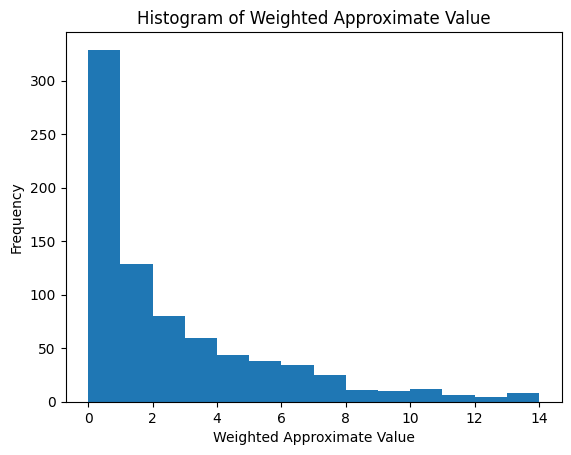

In [11]:
bin_width = 1

bins = np.arange(min(y_nona), max(y_nona) + bin_width, bin_width)

plt.hist(y_nona, bins = bins)
plt.ylabel('Frequency')
plt.xlabel('Weighted Approximate Value')
plt.title('Histogram of Weighted Approximate Value')
plt.show()

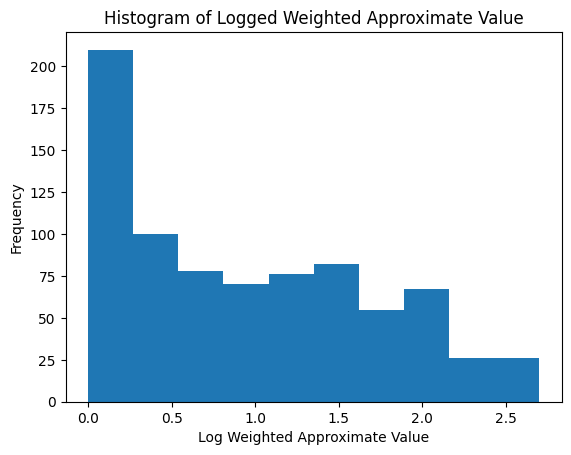

In [12]:
y_log = y_nona.copy()
y_log = np.log(y_log + 1)

plt.hist(y_log)
plt.ylabel('Frequency')
plt.xlabel('Log Weighted Approximate Value')
plt.title('Histogram of Logged Weighted Approximate Value')
plt.show()

In [13]:
y_log.value_counts()

adjusted_w_av
0.000000    175
0.693147     49
0.405465     39
1.098612     36
1.386294     23
           ... 
2.427748      1
2.662588      1
2.169054      1
2.564949      1
2.159484      1
Name: count, Length: 185, dtype: int64

In [33]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split


train_x, test_x, train_y, test_y = train_test_split(X_nona, y_nona, test_size = 0.3)

# num_cols = train_x.select_dtypes(include=np.number).columns
# cat_cols = train_x.select_dtypes(include=['str', 'category']).columns


# # Create transformer
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(), num_cols)
#     ],
#     remainder='passthrough',
#     verbose_feature_names_out=False
# )

# preprocessor.set_output(transform="pandas")

# # Fit on training data, transform both
# train_x = preprocessor.fit_transform(train_x)
# test_x = preprocessor.transform(test_x)

In [15]:
train_x

,position_x,usage_overall,avg_ppa_all,total_ppa_all,conference,fumbles_FUM,fumbles_LOST,passing_ATT,passing_COMPLETIONS,passing_PCT,INT_pct,passing_TD,passing_YDS,passing_YPA,receiving_REC,receiving_TD,receiving_YDS,receiving_YPR,rushing_ATT,rushing_TD,rushing_YDS,rushing_YPC,age,height,weight
1856,RB,0.160429,0.222714,32.353571,SEC,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.00,16.428571,0.571429,160.000000,10.457143,116.571429,6.428571,737.571429,6.214286,24.0,72.0,204.0
3968,TE,0.034167,0.866833,22.613000,SEC,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.00,22.833333,2.666667,313.166667,13.450000,0.000000,0.000000,0.000000,0.000000,22.0,75.0,244.0
10,WR,0.114400,0.792400,79.568000,B1G,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.00,66.200000,10.300000,1027.400000,15.490000,0.000000,0.000000,0.000000,0.000000,22.0,73.0,208.0
3573,TE,0.073800,0.699700,40.640400,B1G,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.00,40.600000,4.400000,595.000000,15.200000,0.000000,0.000000,0.000000,0.000000,23.0,76.0,245.0
7981,WR,0.161667,0.704500,77.491833,B1G,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.00,78.500000,6.833333,1023.833333,12.833333,0.000000,0.000000,0.000000,0.000000,22.0,73.0,212.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45,QB,0.524000,0.098000,44.653000,B1G,0.000000,0.0,392.0,228.000000,0.582000,0.028061,7.0,2214.000000,5.60,1.000000,1.000000,17.000000,17.000000,68.000000,5.000000,-123.000000,-1.800000,24.0,75.0,220.0
7529,QB,0.590833,0.503000,239.076167,PAC,6.333333,2.0,395.5,266.333333,0.672167,0.012221,32.5,3646.833333,9.25,0.000000,0.000000,0.000000,0.000000,100.333333,9.833333,258.500000,2.666667,23.0,73.0,226.0
6451,RB,0.285000,0.316000,91.030000,AAC,3.000000,1.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.00,51.000000,3.000000,610.000000,12.000000,231.000000,13.000000,1459.000000,6.300000,22.0,69.0,200.0
3949,TE,0.032583,0.944833,4.831333,B1G,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.00,3.916667,0.750000,56.333333,14.708333,0.000000,0.000000,0.000000,0.000000,24.0,77.0,265.0


In [76]:
import numpy as np

class GammaObjective(object):
    def calc_ders_range(self, approxes, targets, weights):
        # Numba loves simple, explicit loops. It will compile this to C-speed.
        result = []
        
        for i in range(len(targets)):
            # 1. Get the raw prediction and clip it manually 
            # (Numba handles basic if/else much better than np.clip)
            approx = approxes[i]
            if approx > 20.0:
                approx = 20.0
            elif approx < -20.0:
                approx = -20.0
                
            # Apply log-link
            mu = np.exp(approx)
            
            # 2. Calculate derivatives
            der1 = (targets[i] / mu) - 1.0
            der2 = -(targets[i] / mu)
            
            # 3. Apply weights if they exist
            if weights is not None:
                der1 *= weights[i]
                der2 *= weights[i]
                
            # 4. Append as a tuple
            result.append((der1, der2))
            
        return result

class GammaRMSEMetric(object):
    def get_final_error(self, error, weight):
        # The evaluate method returns the Sum of Squared Errors.
        # Here, we divide by the total weight (or count) and take the square root.
        return np.sqrt(error / (weight + 1e-38))

    def is_max_optimal(self):
        # We are minimizing RMSE, so max is not optimal
        return False

    def evaluate(self, approxes, targets, weights):
        # Numba-friendly loop for evaluation
        approx = approxes[0]
        
        error_sum = 0.0
        weight_sum = 0.0
        
        for i in range(len(targets)):
            # 1. Get raw prediction and clip to prevent np.exp() overflow
            z = approx[i]
            if z > 20.0:
                z = 20.0
            elif z < -20.0:
                z = -20.0
                
            # 2. Transform back to original scale (The expected value)
            mu = np.exp(z)
            
            # 3. Calculate the Squared Error: (y - mu)^2
            sq_error = (targets[i] - mu) ** 2
            
            # 4. Accumulate sums
            if weights is not None:
                w = weights[i]
                error_sum += sq_error * w
                weight_sum += w
            else:
                error_sum += sq_error
                weight_sum += 1.0
                
        # Return the total Sum of Squared Errors and the total weight
        return error_sum, weight_sum

In [77]:
from catboost import CatBoostRegressor

# finds categorical features
cat_features = train_x.select_dtypes(include=['str', 'category']).columns
cat_indices = [train_x.columns.get_loc(col) for col in cat_features]

model = CatBoostRegressor(
    iterations=2000,
    depth=3,
    learning_rate=0.05,
    loss_function=GammaObjective(),
    eval_metric = GammaRMSEMetric(),
    l2_leaf_reg = 10,
    verbose=100
)

model.fit(
    train_x,
    (train_y + 1),
    eval_set = (test_x, test_y + 1),
    cat_features=cat_indices # assigns categorical features
)

preds = model.predict(test_x)

0:	learn: 3.7042600	test: 4.0448474	best: 4.0448474 (0)	total: 1.37s	remaining: 45m 42s
100:	learn: 2.5529182	test: 2.9228450	best: 2.9228450 (100)	total: 1.56s	remaining: 29.3s
200:	learn: 2.3205804	test: 2.8381675	best: 2.8374464 (187)	total: 1.81s	remaining: 16.2s
300:	learn: 2.1801499	test: 2.8260135	best: 2.8247931 (293)	total: 2.06s	remaining: 11.6s
400:	learn: 2.0738589	test: 2.8185343	best: 2.8143366 (383)	total: 2.25s	remaining: 8.98s
500:	learn: 2.0086857	test: 2.8104857	best: 2.8071657 (457)	total: 2.46s	remaining: 7.37s
600:	learn: 1.9423729	test: 2.8020869	best: 2.8001141 (598)	total: 2.63s	remaining: 6.13s
700:	learn: 1.8915974	test: 2.8111836	best: 2.8001141 (598)	total: 2.81s	remaining: 5.2s
800:	learn: 1.8482662	test: 2.8105370	best: 2.8001141 (598)	total: 2.98s	remaining: 4.46s
900:	learn: 1.8042305	test: 2.8168706	best: 2.8001141 (598)	total: 3.15s	remaining: 3.84s
1000:	learn: 1.7624913	test: 2.8126715	best: 2.8001141 (598)	total: 3.31s	remaining: 3.3s
1100:	learn: 

In [78]:
print(f"{"="*10}Raw Predictions{"="*10}\n{preds}")
print(f"{"="*10}Exponentiated Predictions{"="*10}\n{np.exp(preds) - 1}")

==========Raw Predictions==========
[1.15325195 1.04942546 1.45266791 1.68717326 1.35570069 1.3669741
 0.89586517 1.48217906 1.29852461 0.77993573 1.32466532 1.34819639
 0.65601447 0.553892   0.7447293  1.37828652 1.8696363  0.81473522
 1.14241753 0.70911795 0.85685111 0.96038463 1.43123646 0.87524354
 1.3621336  1.16177733 0.72950728 0.62956708 0.86828699 0.6783263
 0.6427901  1.89219541 1.38855755 1.21306538 1.39077586 1.04293216
 1.36178211 1.47587375 1.15774071 1.16143413 1.20079249 0.68439473
 0.77961135 1.16531387 1.15380927 0.60820854 0.67442186 1.35608012
 1.24451354 1.20979424 1.74229241 0.75385026 1.24151469 1.02329051
 1.17514187 1.68006916 0.92063162 0.6213202  1.37104609 0.82593888
 0.82988232 1.60854782 1.27436615 0.48182729 0.33554595 1.39548993
 1.9180309  0.98901267 1.87012255 1.26173803 0.99351174 1.1312997
 1.32788593 0.68292538 1.66826587 1.45314449 1.86052744 0.70843347
 0.64713946 0.75700135 0.9231788  0.62941418 1.51649258 1.74090245
 1.93890025 0.70839144 0.4705

In [79]:
from sklearn.metrics import root_mean_squared_error as rmse
preds_exp = np.exp(preds) - 1
#test_y_exp = np.exp(test_y) - 1

test_rmse = rmse(test_y, preds_exp)

print(f"Test RMSE: {test_rmse:.2f}")

Test RMSE: 2.80


In [84]:
from catboost import cv, Pool

cv_dataset = Pool(data=train_x, label=train_y, cat_features=cat_indices)

params = {
    "iterations": 2000,
    "depth": 3,
    "loss_function": GammaObjective(),
    "eval_metric": GammaRMSEMetric(),
    "l2_leaf_reg": 10,
    "verbose": 100
}

# This will run cleanly without cloning errors
cv_results = cv(
    pool=cv_dataset,
    params=params,
    fold_count=5,
    early_stopping_rounds=50, 
    return_models=False 
)

print(f"\nBest Test RMSE: {cv_results['test-GammaRMSEMetric-mean'].min():.4f}")

Training on fold [0/5]
0:	learn: 3.2160369	test: 2.9890760	best: 2.9890760 (0)	total: 331ms	remaining: 11m
100:	learn: 2.6739865	test: 2.6166415	best: 2.6166415 (100)	total: 524ms	remaining: 9.85s
200:	learn: 2.4501599	test: 2.5399353	best: 2.5399353 (200)	total: 720ms	remaining: 6.44s
300:	learn: 2.3235013	test: 2.5379020	best: 2.5350852 (264)	total: 976ms	remaining: 5.51s
400:	learn: 2.2164036	test: 2.5234855	best: 2.5213518 (383)	total: 1.25s	remaining: 5.01s

bestTest = 2.518099845
bestIteration = 433

Training on fold [1/5]
0:	learn: 3.2118228	test: 3.0071554	best: 3.0071554 (0)	total: 1.57ms	remaining: 3.15s
100:	learn: 2.6543909	test: 2.6826858	best: 2.6826858 (100)	total: 199ms	remaining: 3.75s
200:	learn: 2.4456922	test: 2.6251103	best: 2.6251103 (200)	total: 383ms	remaining: 3.43s
300:	learn: 2.3253258	test: 2.6018705	best: 2.6005210 (298)	total: 567ms	remaining: 3.2s

bestTest = 2.597956722
bestIteration = 345

Training on fold [2/5]
0:	learn: 3.1128114	test: 3.3967762	best:

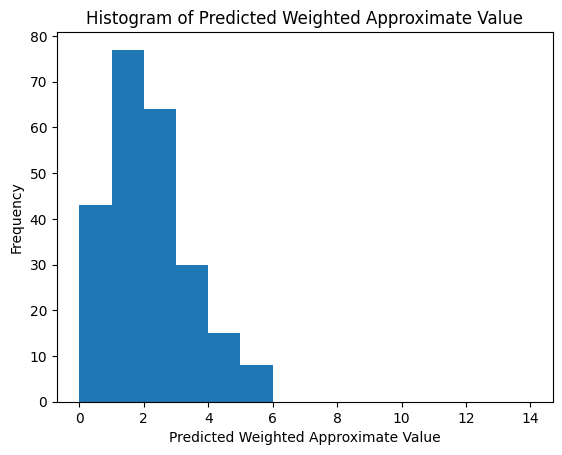

In [85]:
plt.hist(preds_exp, bins = bins)
plt.ylabel('Frequency')
plt.xlabel('Predicted Weighted Approximate Value')
plt.title('Histogram of Predicted Weighted Approximate Value')
plt.show()

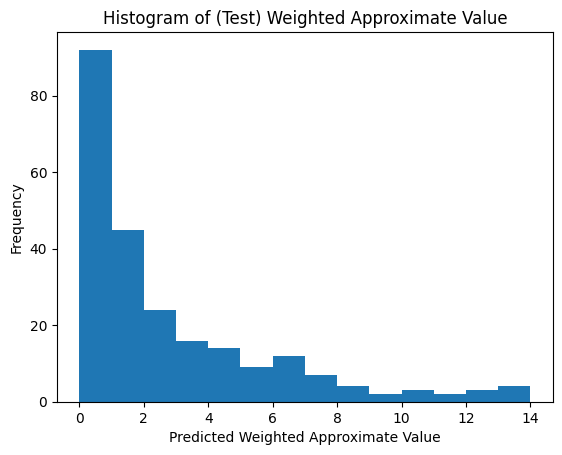

In [82]:
plt.hist(test_y, bins = bins)
plt.ylabel('Frequency')
plt.xlabel('Predicted Weighted Approximate Value')
plt.title('Histogram of (Test) Weighted Approximate Value')
plt.show()

In [228]:
from sklearn.model_selection import KFold
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error as rmse # Re-import rmse here to ensure it's a function

kf = KFold(n_splits=10, shuffle=True, random_state=101)

rmse_scores = []

# Define numerical and categorical columns for the preprocessor, based on X_nona structure.
# These were implicitly identified in the previous preprocessing step (NYVxNwb6PztL).
# Ensuring they are explicitly available here for clarity and correctness.
num_cols_original = X_nona.select_dtypes(include=np.number).columns
cat_cols_original = X_nona.select_dtypes(include='object').columns


for train_idx, val_idx in kf.split(X_nona):
    X_train_fold, X_val_fold = X_nona.iloc[train_idx], X_nona.iloc[val_idx]
    y_train_fold, y_val_fold = y_log.iloc[train_idx], y_log.iloc[val_idx]

    # Create a new preprocessor for each fold to fit the scaler on the training fold
    # This avoids data leakage from the validation fold.
    preprocessor_fold = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols_original) # Apply StandardScaler to numerical columns
        ],
        remainder='passthrough', # Keep categorical columns as they are for CatBoost
        verbose_feature_names_out=False
    )
    preprocessor_fold.set_output(transform="pandas")

    X_train_processed = preprocessor_fold.fit_transform(X_train_fold)
    X_val_processed = preprocessor_fold.transform(X_val_fold)

    # Identify categorical feature indices in the processed data for CatBoost
    cat_features_in_processed_data = X_train_processed.select_dtypes(include=['object', 'category']).columns
    cat_indices_fold = [X_train_processed.columns.get_loc(col) for col in cat_features_in_processed_data]

    model = CatBoostRegressor(
        iterations=2000,
        depth=6,
        learning_rate=0.05,
        loss_function='RMSE',
        verbose=1000,
        l2_leaf_reg = 10,
        random_seed=101 # Added random_seed for reproducibility
    )

    model.fit(
        X_train_processed,
        y_train_fold,
        eval_set = (X_val_processed, y_val_fold),
        cat_features=cat_indices_fold
    )

    preds = model.predict(X_val_processed)

    preds_exp = np.exp(preds) - 1
    test_y_exp = np.exp(y_val_fold) - 1

    test_rmse = rmse(test_y_exp, preds_exp)

    rmse_scores.append(test_rmse)

print(f"CV RMSE: {round(np.mean(rmse_scores),2)}")

0:	learn: 0.7615862	test: 0.8176041	best: 0.8176041 (0)	total: 7.82ms	remaining: 15.6s
1000:	learn: 0.3062265	test: 0.7367422	best: 0.7231914 (173)	total: 6.38s	remaining: 6.37s
1999:	learn: 0.1839003	test: 0.7409859	best: 0.7231914 (173)	total: 11.4s	remaining: 0us

bestTest = 0.7231913745
bestIteration = 173

Shrink model to first 174 iterations.
0:	learn: 0.7641433	test: 0.8024851	best: 0.8024851 (0)	total: 5.52ms	remaining: 11s
1000:	learn: 0.3133638	test: 0.7354668	best: 0.7345717 (790)	total: 6.46s	remaining: 6.45s
1999:	learn: 0.1841648	test: 0.7317029	best: 0.7314573 (1794)	total: 11.5s	remaining: 0us

bestTest = 0.7314572866
bestIteration = 1794

Shrink model to first 1795 iterations.
0:	learn: 0.7684157	test: 0.7630714	best: 0.7630714 (0)	total: 6.08ms	remaining: 12.2s
1000:	learn: 0.3174315	test: 0.6941698	best: 0.6836515 (203)	total: 6.27s	remaining: 6.26s
1999:	learn: 0.1761649	test: 0.7067326	best: 0.6836515 (203)	total: 10.9s	remaining: 0us

bestTest = 0.6836514752
bestI

In [229]:
y_log.describe()

,adjusted_w_av
count,790.000000
mean,0.926980
std,0.772268
min,0.000000
25%,0.223144
50%,0.810930
75%,1.545783
max,2.699682


# RandomForest

In [230]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error as rmse # Re-import rmse here to ensure it's a function

kf = KFold(n_splits=10, shuffle=True, random_state=101)

rmse_scores = []

# Define numerical and categorical columns for the preprocessor, based on X_nona structure.
# These were implicitly identified in the previous preprocessing step (NYVxNwb6PztL).
# Ensuring they are explicitly available here for clarity and correctness.
num_cols_original = X_nona.select_dtypes(include=np.number).columns
cat_cols_original = X_nona.select_dtypes(include='object').columns


for train_idx, val_idx in kf.split(X_nona):
    X_train_fold, X_val_fold = X_nona.iloc[train_idx], X_nona.iloc[val_idx]
    y_train_fold, y_val_fold = y_log.iloc[train_idx], y_log.iloc[val_idx]

    # Create a new preprocessor for each fold to fit the scaler on the training fold
    # This avoids data leakage from the validation fold.
    preprocessor_fold = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols_original), # Apply StandardScaler to numerical columns
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_original) # Apply OneHotEncoder to categorical columns
        ],
    )
    preprocessor_fold.set_output(transform="pandas")

    X_train_processed = preprocessor_fold.fit_transform(X_train_fold)
    X_val_processed = preprocessor_fold.transform(X_val_fold)

    # Identify categorical feature indices in the processed data for CatBoost
    cat_features_in_processed_data = X_train_processed.select_dtypes(include=['object', 'category']).columns
    cat_indices_fold = [X_train_processed.columns.get_loc(col) for col in cat_features_in_processed_data]

    model = RandomForestRegressor(
        n_estimators = 1000,
        max_features = 'sqrt'
    )

    model.fit(
        X_train_processed,
        y_train_fold
    )

    preds = model.predict(X_val_processed)

    preds_exp = np.exp(preds) - 1
    test_y_exp = np.exp(y_val_fold) - 1

    test_rmse = rmse(test_y_exp, preds_exp)

    rmse_scores.append(test_rmse)

print(f"CV RMSE: {round(np.mean(rmse_scores),2)}")

CV RMSE: 2.75


# **XGBoost**

In [3]:
%%capture
! pip install xgboost

In [232]:
from sklearn.model_selection import KFold
from xgboost import XGBRegressor
import xgboost as xgb
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error as rmse # Re-import rmse here to ensure it's a function

kf = KFold(n_splits=10, shuffle=True, random_state=101)

rmse_scores = []

# Define numerical and categorical columns for the preprocessor, based on X_nona structure.
# These were implicitly identified in the previous preprocessing step (NYVxNwb6PztL).
# Ensuring they are explicitly available here for clarity and correctness.
num_cols_original = X_nona.select_dtypes(include=np.number).columns
cat_cols_original = X_nona.select_dtypes(include='object').columns


for train_idx, val_idx in kf.split(X_nona):
    X_train_fold, X_val_fold = X_nona.iloc[train_idx], X_nona.iloc[val_idx]
    y_train_fold, y_val_fold = y_log.iloc[train_idx], y_log.iloc[val_idx]

    # Create a new preprocessor for each fold to fit the scaler on the training fold
    # This avoids data leakage from the validation fold.
    preprocessor_fold = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols_original), # Apply StandardScaler to numerical columns
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_original) # Apply OneHotEncoder to categorical columns
        ],
    )
    preprocessor_fold.set_output(transform="pandas")

    X_train_processed = preprocessor_fold.fit_transform(X_train_fold)
    X_val_processed = preprocessor_fold.transform(X_val_fold)

    # Identify categorical feature indices in the processed data for CatBoost
    cat_features_in_processed_data = X_train_processed.select_dtypes(include=['object', 'category']).columns
    cat_indices_fold = [X_train_processed.columns.get_loc(col) for col in cat_features_in_processed_data]

    model = XGBRegressor(
        n_estimators = 1000,
        objective = 'reg:squarederror',
        learning_rate = 0.05,
        max_depth = 6,
        random_state = 101,
        reg_lambda = 5,
        eval_metric = 'rmse'
    )

    model.fit(
        X_train_processed,
        y_train_fold,
        eval_set = [(X_val_processed, y_val_fold)],
        verbose = 1000
    )

    preds = model.predict(X_val_processed)

    preds_exp = np.exp(preds) - 1
    test_y_exp = np.exp(y_val_fold) - 1

    test_rmse = rmse(test_y_exp, preds_exp)

    rmse_scores.append(test_rmse)

print(f"CV RMSE: {round(np.mean(rmse_scores),2)}")

[0]	validation_0-rmse:0.81638
[999]	validation_0-rmse:0.76985
[0]	validation_0-rmse:0.80013
[999]	validation_0-rmse:0.78804
[0]	validation_0-rmse:0.75967
[999]	validation_0-rmse:0.75287
[0]	validation_0-rmse:0.72359
[999]	validation_0-rmse:0.72237
[0]	validation_0-rmse:0.74848
[999]	validation_0-rmse:0.70161
[0]	validation_0-rmse:0.72682
[999]	validation_0-rmse:0.67907
[0]	validation_0-rmse:0.82438
[999]	validation_0-rmse:0.75349
[0]	validation_0-rmse:0.78265
[999]	validation_0-rmse:0.76562
[0]	validation_0-rmse:0.78780
[999]	validation_0-rmse:0.74051
[0]	validation_0-rmse:0.68916
[999]	validation_0-rmse:0.69158
CV RMSE: 2.75
